In [3]:
import os
import random
import shutil
import kagglehub
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [4]:
# Configuration
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device utilisé : {DEVICE}")


Device utilisé : cuda


In [20]:
# Hyperparamètres
BATCH_SIZE = 32
NUM_EPOCHS = 25
LEARNING_RATE = 0.001
IMG_SIZE = 224
TARGET_CLASSES = ['cardboard', 'metal', 'paper', 'plastic', 'trash']  #  5 classes

In [6]:
# Vérifier GPU
if torch.cuda.is_available():
    print(f"GPU détecté : {torch.cuda.get_device_name(0)}")
else:
    print("Pas de GPU, utilisation du CPU (plus lent)")

GPU détecté : Tesla T4


In [7]:
# ============================================================
# Monter Google Drive pour sauvegarder les résultats
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

# Créer le dossier de sortie
OUTPUT_DIR = '/content/drive/MyDrive/EcoTri/results'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Les résultats seront sauvegardés dans : {OUTPUT_DIR}")

Mounted at /content/drive
Les résultats seront sauvegardés dans : /content/drive/MyDrive/EcoTri/results


In [8]:
# ============================================================
# Télécharger le dataset via l'API officielle KaggleHub
# ============================================================
import kagglehub
import os

# Dataset officiel Garbage Classification (6 classes : cardboard, glass, metal, paper, plastic, trash)
# Source : https://www.kaggle.com/datasets/mostafaabla/garbage-classification
dataset_handle = "mostafaabla/garbage-classification"

print(f"Téléchargement du dataset '{dataset_handle}' en cours...")

# Téléchargement et extraction automatique
path = kagglehub.dataset_download(dataset_handle)

print(f"Dataset téléchargé et extrait avec succès !")
print(f"Chemin d'accès : {path}")

Téléchargement du dataset 'mostafaabla/garbage-classification' en cours...
Using Colab cache for faster access to the 'garbage-classification' dataset.
Dataset téléchargé et extrait avec succès !
Chemin d'accès : /kaggle/input/garbage-classification


In [9]:
# ============================================================
# PRÉPARATION DES DONNÉES (Version nettoyante)
# ============================================================
import shutil
import random
from pathlib import Path

SOURCE_DIR = Path(path)
TARGET_DIR = Path('/content/data/garbage_classification')

# ÉTAPE CRUCIALE : Nettoyer complètement le dossier cible
if TARGET_DIR.exists():
    shutil.rmtree(TARGET_DIR)
    print(f" Ancien dossier supprimé : {TARGET_DIR}")

# 1. Trouver le dossier parent qui contient les classes
base_class_dir = None
for item in SOURCE_DIR.rglob('*'):
    if item.is_dir() and item.name.lower() in [c.lower() for c in TARGET_CLASSES]:
        base_class_dir = item.parent
        break

if base_class_dir is None:
    raise Exception(f" Impossible de trouver les dossiers de classes dans {SOURCE_DIR}")

print(f" Dossier des classes identifié : {base_class_dir}")

# 2. Créer la structure cible propre
for split in ['train', 'test']:
    for class_name in TARGET_CLASSES:
        (TARGET_DIR / split / class_name).mkdir(parents=True, exist_ok=True)

# 3. Extensions d'images valides
valid_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.webp', '.tif', '.tiff', '.ppm', '.pgm'}

# 4. Répartir les images (80% train, 20% test)
random.seed(42)

for class_name in TARGET_CLASSES:
    class_dir = base_class_dir / class_name
    if not class_dir.exists():
        print(f" Dossier '{class_name}' non trouvé, ignoré.")
        continue

    # Récupérer uniquement les images valides
    images = [f for f in class_dir.iterdir()
              if f.is_file() and f.suffix.lower() in valid_extensions]

    if len(images) == 0:
        print(f" ALERTE : Aucune image valide dans '{class_name}'.")
        continue

    random.shuffle(images)
    split_idx = int(len(images) * 0.8)

    for img in images[:split_idx]:
        shutil.copy(img, TARGET_DIR / 'train' / class_name / img.name)
    for img in images[split_idx:]:
        shutil.copy(img, TARGET_DIR / 'test' / class_name / img.name)

    print(f" {class_name.ljust(10)} : {len(images[:split_idx]):3d} train, {len(images[split_idx:]):3d} test")

# 5. Vérification finale
print("\n Vérification de la structure cible :")
for split in ['train', 'test']:
    total = sum(1 for _ in (TARGET_DIR / split).rglob('*') if _.is_file())
    print(f"   - {split} : {total} fichiers au total")

print(f"\n Données préparées avec succès dans : {TARGET_DIR}")

 Dossier des classes identifié : /kaggle/input/garbage-classification/garbage_classification
 cardboard  : 712 train, 179 test
 metal      : 615 train, 154 test
 paper      : 840 train, 210 test
 plastic    : 692 train, 173 test
 trash      : 557 train, 140 test

 Vérification de la structure cible :
   - train : 3416 fichiers au total
   - test : 856 fichiers au total

 Données préparées avec succès dans : /content/data/garbage_classification


In [10]:
# ============================================================
# PRÉPARATION DES DONNÉES (Transforms & DataLoaders)
# ============================================================
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

image_datasets = {
    'train': datasets.ImageFolder(TARGET_DIR / 'train', train_transforms),
    'test': datasets.ImageFolder(TARGET_DIR / 'test', test_transforms)
}

dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=BATCH_SIZE, shuffle=True, num_workers=2),
    'test': DataLoader(image_datasets['test'], batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
}

CLASS_NAMES = image_datasets['train'].classes
print(f" Classes détectées : {CLASS_NAMES}")
print(f" Images d'entraînement : {len(image_datasets['train'])}")
print(f" Images de test : {len(image_datasets['test'])}")

 Classes détectées : ['cardboard', 'metal', 'paper', 'plastic', 'trash']
 Images d'entraînement : 3416
 Images de test : 856


In [11]:
# ============================================================
#  MODÉLISATION (Architecture du modèle)
# ============================================================
def create_model(num_classes, freeze_base=True):
    """
    Crée un modèle ResNet18 avec Transfer Learning.
    Args:
        num_classes: nombre de classes de sortie (dynamique, ici 5)
        freeze_base: si True, gèle les poids de la base pour un entraînement plus rapide
    """
    # Charger un modèle ResNet18 pré-entraîné sur ImageNet
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    # Geler les paramètres de la base (feature extractor)
    if freeze_base:
        for param in model.parameters():
            param.requires_grad = False

    # Remplacer la couche de classification finale (fully connected)
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),          # Régularisation pour éviter l'overfitting
        nn.Linear(num_ftrs, 256),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, num_classes) # Sortie adaptée au nombre de classes (5)
    )

    return model

# Initialisation du modèle
model = create_model(num_classes=len(CLASS_NAMES)).to(DEVICE)

# Fonction de perte et optimiseur
criterion = nn.CrossEntropyLoss()
# On n'optimise que les paramètres de la tête du réseau (ceux qui ne sont pas gelés)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE)

print(f"Modèle créé avec succès.")
print(f" Nombre de classes de sortie : {len(CLASS_NAMES)}")
print(f" Paramètres entraînables : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s]


Modèle créé avec succès.
 Nombre de classes de sortie : 5
 Paramètres entraînables : 132,613


In [12]:
# ============================================================
# MODÉLISATION (Boucle d'entraînement)
# ============================================================
def train_model(model, dataloaders, criterion, optimizer, device, num_epochs=15):
    """Boucle d'entraînement et de validation du modèle."""
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f"\n--- Epoch {epoch+1}/{num_epochs} ---")

        # --- PHASE D'ENTRAÎNEMENT ---
        model.train()
        running_loss, running_corrects, total = 0.0, 0, 0
        pbar = tqdm(dataloaders['train'], desc='Train')

        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += (preds == labels).sum().item()
            total += labels.size(0)
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        epoch_loss = running_loss / total
        epoch_acc = running_corrects / total
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc)

        # --- PHASE DE TEST / VALIDATION ---
        model.eval()
        test_loss, test_corrects, test_total = 0.0, 0, 0

        with torch.no_grad():
            for inputs, labels in dataloaders['test']:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)

                test_loss += loss.item() * inputs.size(0)
                test_corrects += (preds == labels).sum().item()
                test_total += labels.size(0)

        test_epoch_loss = test_loss / test_total
        test_epoch_acc = test_corrects / test_total
        history['test_loss'].append(test_epoch_loss)
        history['test_acc'].append(test_epoch_acc)

        print(f" Train Acc: {epoch_acc:.4f} | Test Acc: {test_epoch_acc:.4f}")

        # Sauvegarder le meilleur modèle
        if test_epoch_acc > best_acc:
            best_acc = test_epoch_acc
            torch.save(model.state_dict(), '/content/best_model.pth')
            print(f" [NOUVEAU RECORD] Meilleur modèle sauvegardé (acc={best_acc:.4f})")

    return history

In [21]:
# ============================================================
# MODÉLISATION (Exécution d'entraînement)
# ============================================================
print("Démarrage de l'entraînement...")
history = train_model(model, dataloaders, criterion, optimizer, DEVICE, num_epochs=NUM_EPOCHS)
print("\nEntraînement terminé avec succès !")

Démarrage de l'entraînement...

--- Epoch 1/25 ---


Train: 100%|██████████| 107/107 [00:16<00:00,  6.49it/s, loss=0.3687]


 Train Acc: 0.7761 | Test Acc: 0.8668
 [NOUVEAU RECORD] Meilleur modèle sauvegardé (acc=0.8668)

--- Epoch 2/25 ---


Train: 100%|██████████| 107/107 [00:17<00:00,  6.06it/s, loss=0.5547]


 Train Acc: 0.7889 | Test Acc: 0.8984
 [NOUVEAU RECORD] Meilleur modèle sauvegardé (acc=0.8984)

--- Epoch 3/25 ---


...

 Train Acc: 0.8153 | Test Acc: 0.9042

--- Epoch 24/25 ---


Train: 100%|██████████| 107/107 [00:16<00:00,  6.61it/s, loss=0.3542]


 Train Acc: 0.8290 | Test Acc: 0.9077

--- Epoch 25/25 ---


Train: 100%|██████████| 107/107 [00:15<00:00,  6.72it/s, loss=0.7155]


 Train Acc: 0.8173 | Test Acc: 0.9100

Entraînement terminé avec succès !


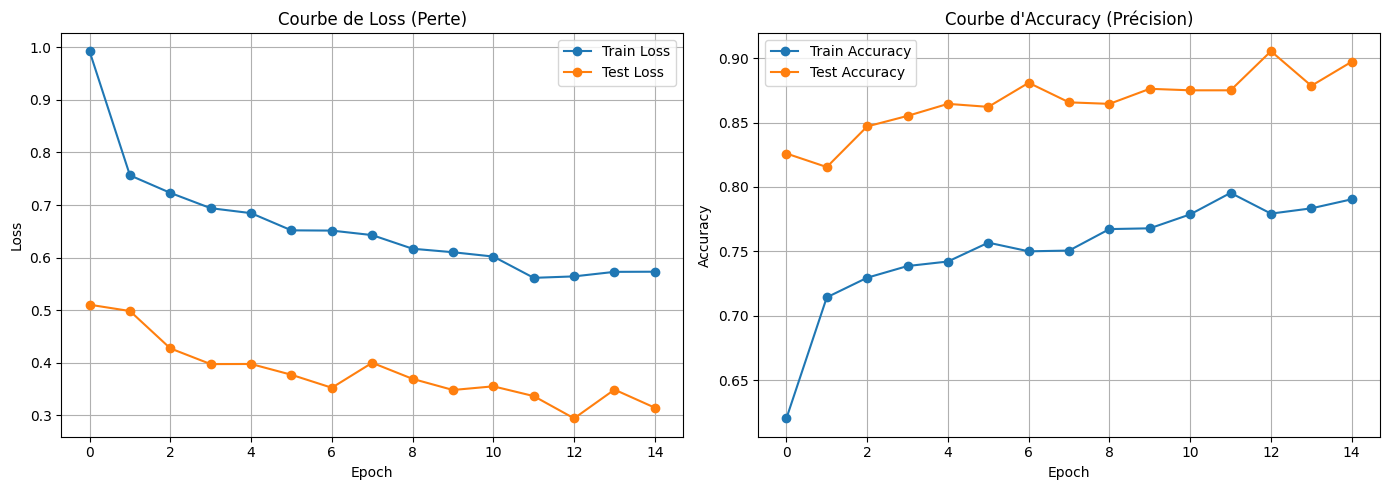

Courbes d'apprentissage sauvegardées : /content/training_curves.png


In [14]:
# ============================================================
# ÉVALUATION (Courbes d'apprentissage)
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Courbe de Loss
ax1.plot(history['train_loss'], label='Train Loss', marker='o')
ax1.plot(history['test_loss'], label='Test Loss', marker='o')
ax1.set_title('Courbe de Loss (Perte)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Courbe d'Accuracy
ax2.plot(history['train_acc'], label='Train Accuracy', marker='o')
ax2.plot(history['test_acc'], label='Test Accuracy', marker='o')
ax2.set_title('Courbe d\'Accuracy (Précision)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("Courbes d'apprentissage sauvegardées : /content/training_curves.png")

In [16]:
# ============================================================
# ÉVALUATION (Calcul des métriques globales)
# ============================================================
# Charger le meilleur modèle pour l'évaluation finale
model.load_state_dict(torch.load('/content/best_model.pth'))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in tqdm(dataloaders['test'], desc='Évaluation sur le jeu de test'):
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

y_true = np.array(all_labels)
y_pred = np.array(all_preds)

# Calcul des métriques (average='macro' pour traiter toutes les classes équitablement)
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

print("\n" + "="*70)
print(" MÉTRIQUES GLOBALES")
print("="*70)
print(f"  Accuracy  : {accuracy:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-score  : {f1:.4f}")
print("="*70)

Évaluation sur le jeu de test: 100%|██████████| 27/27 [00:04<00:00,  6.17it/s]


 MÉTRIQUES GLOBALES
  Accuracy  : 0.9054
  Precision : 0.9076
  Recall    : 0.9040
  F1-score  : 0.9050


In [17]:
# ============================================================
# ÉVALUATION (Rapport de classification détaillé)
# ============================================================
print("\nRAPPORT DE CLASSIFICATION DÉTAILLÉ PAR CLASSE :")
print("-" * 70)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))
print("-" * 70)


RAPPORT DE CLASSIFICATION DÉTAILLÉ PAR CLASSE :
----------------------------------------------------------------------
              precision    recall  f1-score   support

   cardboard       0.97      0.94      0.95       179
       metal       0.92      0.84      0.88       154
       paper       0.88      0.95      0.91       210
     plastic       0.86      0.83      0.85       173
       trash       0.91      0.96      0.93       140

    accuracy                           0.91       856
   macro avg       0.91      0.90      0.90       856
weighted avg       0.91      0.91      0.90       856

----------------------------------------------------------------------


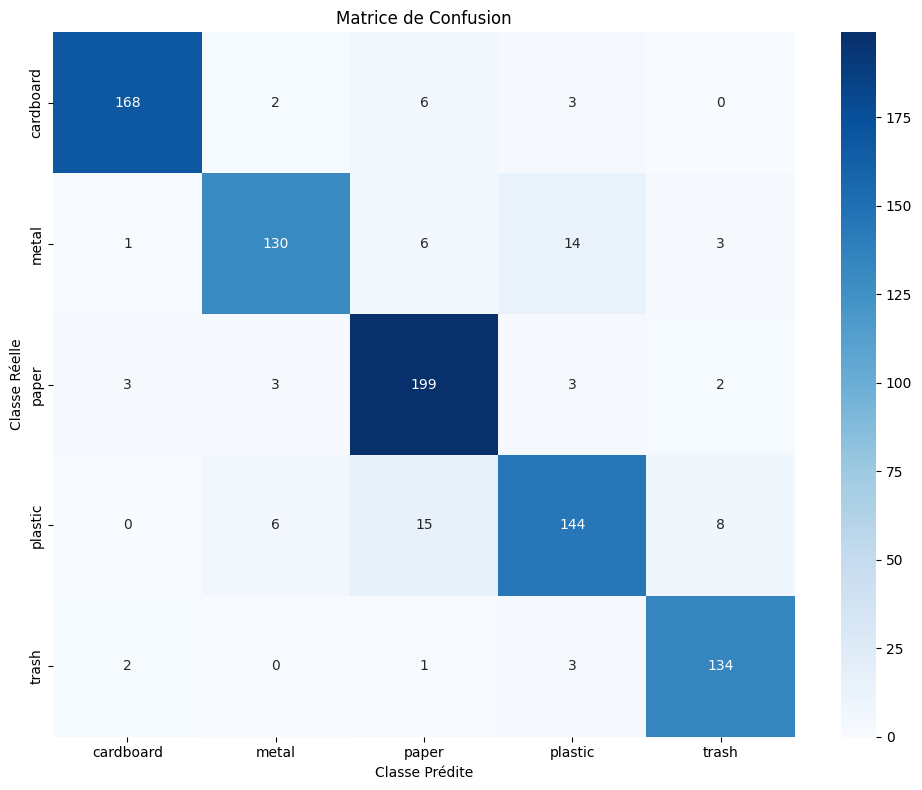

Matrice de confusion sauvegardée : /content/confusion_matrix.png


In [18]:
# ============================================================
# ÉVALUATION (Matrice de confusion)
# ============================================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Classe Prédite')
plt.ylabel('Classe Réelle')
plt.title('Matrice de Confusion')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("Matrice de confusion sauvegardée : /content/confusion_matrix.png")

In [19]:
# ============================================================
# DÉPLOIEMENT (Sauvegarde des artefacts)
# ============================================================
# 1. Générer le rapport texte complet
report_text = "="*70 + "\n"
report_text += "RAPPORT D'ÉVALUATION - Classification de Déchets (Projet M2)\n"
report_text += "="*70 + "\n\n"
report_text += "MÉTRIQUES GLOBALES :\n"
report_text += f"  Accuracy  (Macro) : {accuracy:.4f}\n"
report_text += f"  Precision (Macro) : {precision:.4f}\n"
report_text += f"  Recall    (Macro) : {recall:.4f}\n"
report_text += f"  F1-score  (Macro) : {f1:.4f}\n\n"
report_text += "RAPPORT DÉTAILLÉ PAR CLASSE :\n" + "-"*70 + "\n"
report_text += classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0)
report_text += "-"*70 + "\n"

with open('/content/metrics_report.txt', 'w', encoding='utf-8') as f:
    f.write(report_text)

# 2. Monter Google Drive pour une sauvegarde permanente (recommandé)
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
drive_results_dir = '/content/drive/MyDrive/EcoTri_M2/results'
os.makedirs(drive_results_dir, exist_ok=True)

# 3. Copier tous les livrables dans Drive
files_to_save = ['best_model.pth', 'training_curves.png', 'confusion_matrix.png', 'metrics_report.txt']
for f in files_to_save:
    shutil.copy(f'/content/{f}', f'{drive_results_dir}/{f}')

print(f"TOUS LES LIVRABLES SAUVEGARDÉS DANS GOOGLE DRIVE : {drive_results_dir}")

Mounted at /content/drive
TOUS LES LIVRABLES SAUVEGARDÉS DANS GOOGLE DRIVE : /content/drive/MyDrive/EcoTri_M2/results
